In [1]:
import seaborn as sns

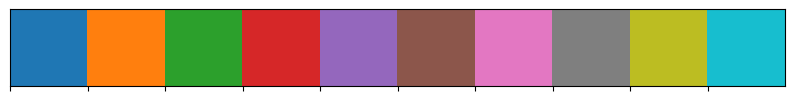

In [2]:
current_palette = sns.color_palette()
sns.palplot(current_palette)

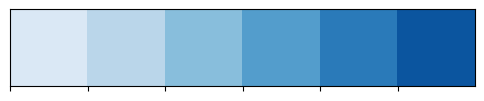

In [3]:
sns.palplot(sns.color_palette('Blues'))

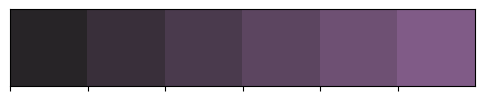

In [4]:
sns.palplot(sns.dark_palette("muted purple", input='xkcd'))

In [5]:
import ssl
# 전역적으로 SSL 검증을 하지 않도록 설정
ssl._create_default_https_context = ssl._create_unverified_context

import seaborn as sns
tips = sns.load_dataset('tips')

In [6]:
# 데이터 시각화를 위한 파이썬 라이브러리인 seaborn을 불러옵니다.
## 코드 작성 시 매번 'seaborn'이라고 길게 입력하지 않도록 보통
#'sns'라는 짧은 별칭(alias)을 지정하여 사용합니다.
import seaborn as sns

## seaborn 라이브러리에서 기본적으로 제공하는 
#교육/테스트용 예제 데이터셋인 'tips'(식당 팁 결제 데이터)를 불러옵니다.
## 불러온 데이터는 표 형태의 데이터를 다루는 데 최적화된 판다스(Pandas) 
#데이터프레임(DataFrame) 형식으로
# 'tips'라는 이름의 변수에 할당(저장)됩니다.
tips = sns.load_dataset('tips')

# 'tips' 변수에 저장된 데이터프레임의 상위 5개 행(row)을 화면에 출력합니다.
## 본격적인 데이터 분석이나 시각화에 앞서, 
#데이터의 전반적인 구조(어떤 열이 있는지, 각 데이터는 어떤 형태인지 등)를
# 빠르고 간단하게 훑어보기 위해 실무에서도 아주 자주 쓰이는 함수입니다.
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
## 'tips' 데이터프레임에 'tip_pct'(팁 비율)라는 
#새로운 열(column)을 생성하여 추가합니다.
## 이 열에는 '순수한 음식 가격 대비 팁을 얼마나 냈는지'에 
#대한 비율이 계산되어 저장됩니다.
#
## 계산 로직의 의미:
## 1. tips["total_bill"]은 식당에서 결제한 '팁이 포함된 총 청구 금액'입니다.
## 2. 따라서 총 청구 금액에서 팁 금액(tips["tip"])을 
#빼주어야 '순수한 음식 가격'이 나옵니다.
##    -> (tips["total_bill"] - tips["tip"])
## 3. 마지막으로 지불한 팁(tips["tip"])을 방금 구한 
#순수 음식 가격으로 나누어 팁의 비율을 구합니다.
tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])

## 방금 계산해서 만든 'tip_pct' 열이 데이터프레임에 
#정상적으로 잘 추가되었는지 확인하기 위해
# 데이터의 상위 5개 행을 출력합니다.
## 결과를 보시면 기존 데이터의 맨 오른쪽 끝에 'tip_pct' 
#열이 새롭게 붙어있는 것을 확인할 수 있습니다.
tips.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,0.063204
1,10.34,1.66,Male,No,Sun,Dinner,3,0.191244
2,21.01,3.50,Male,No,Sun,Dinner,3,0.199886
3,23.68,3.31,Male,No,Sun,Dinner,2,0.162494
4,24.59,3.61,Female,No,Sun,Dinner,4,0.172069


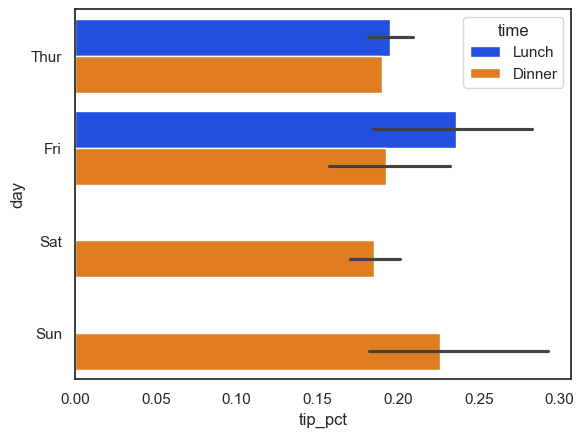

In [8]:
# 파이썬의 가장 대표적인 시각화 라이브러리인 matplotlib의 pyplot 모듈을 불러옵니다.
# seaborn(sns)은 사실 내부적으로 이 matplotlib을 기반으로 작동하기 때문에, 
# 최종적으로 그래프를 화면에 띄우거나 세부적인 설정을 할 때 보통 함께 사용합니다.
import matplotlib.pyplot as plt

# 그래프의 배경 스타일을 설정합니다. "white"는 배경에 격자선(grid)이 없는 깔끔한 흰색 바탕을 의미합니다.
# 주석에 적어주신 것처럼 상황에 맞춰 5가지(darkgrid, whitegrid, ticks, dark, white) 중 하나를 고를 수 있습니다.
sns.set_style("white") # darkgrid, whitegrid, ticks, dark, white

# 그래프가 사용될 목적(화면 크기)에 맞춰 글자 크기나 선의 굵기 등을 자동으로 조절해 주는 설정입니다.
# 'notebook'은 주피터 노트북(Jupyter Notebook) 환경에서 보기에 딱 알맞은 중간 크기로 설정해 줍니다.
# (참고: 크기가 작은 순서대로 paper < notebook < talk < poster(posster) 입니다.)
sns.set_context('notebook') # paper, notebook, talk, posster

# 그래프에 그려질 막대나 선의 색상 테마를 지정합니다. 'bright'는 밝고 선명한 색상 조합을 사용하겠다는 뜻입니다.
# (참고: 기본값인 deep 외에도 muted, pastel(postel), dark, bright, colorblind 등을 지원합니다.)
sns.set_palette('bright') # deep, muted, postel, dark, bright, colorblind

# seaborn의 barplot 함수를 사용해 막대그래프를 그립니다.
# x축에는 이전 단계에서 계산한 '팁 비율(tip_pct)'을, y축에는 '요일(day)'을 배치합니다.
# hue='time'은 같은 요일 안에서도 막대를 '점심(Lunch)'과 '저녁(Dinner)' 시간대별로 나누어 다른 색으로 보여달라는 의미입니다.
# data=tips는 이 그래프를 그릴 때 우리가 앞서 준비한 'tips' 데이터프레임을 사용하겠다는 뜻입니다.
# 작성하신 메모처럼 orient='h'는 막대그래프를 세로가 아닌 가로(수평, horizontal) 방향으로 눕혀서 그리라는 명령어입니다.
sns.barplot(x='tip_pct', y='day', hue='time', data=tips, orient='h') ### orient='h' : 수평이냐 수직이냐

# 위에서 설정하고 그린 그래프를 최종적으로 화면에 출력해서 보여주는 명령어입니다.
plt.show()

# Rug Plot 데이터

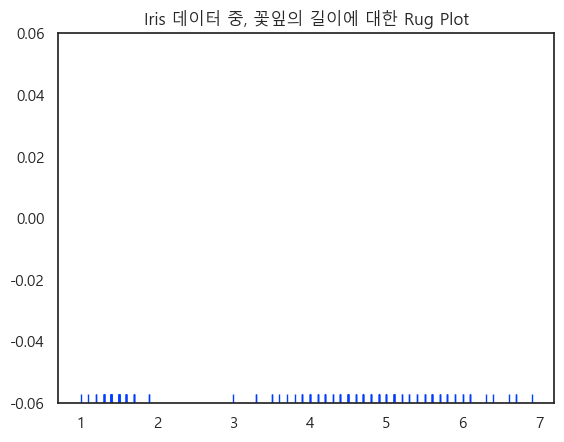

In [9]:
# rug plot 작은 데이터가 어디 위치해 있는지 파악 가능
# (주석 추가: 데이터가 존재하는 x축 위의 위치에 작은 선분(rug)을 그어, 실제 데이터가 어느 구간에 밀집해 있는지 직관적으로 보여줍니다.)

# 데이터 시각화를 위한 핵심 라이브러리인 seaborn을 불러옵니다.
import seaborn as sns
# 그래프의 세부적인 설정(글꼴, 제목 등)과 최종 화면 출력을 담당하는 matplotlib.pyplot 모듈을 불러옵니다.
import matplotlib.pyplot as plt

# seaborn에서 기본으로 제공하는 유명한 통계 학습용 데이터인 '붓꽃(iris)' 데이터셋을 불러옵니다.
iris = sns.load_dataset("iris")

# 불러온 붓꽃 데이터에는 꽃받침 길이/너비, 꽃잎 길이/너비 등의 정보가 있는데, 
# 그중에서 'petal_length'(꽃잎의 길이) 데이터만 콕 집어서 추출한 뒤 'x'라는 변수에 저장합니다.
x = iris.petal_length.values

# --- 한글 깨짐 방지 설정 시작 ---
# 파이썬 그래프에서 제목 등에 한글을 쓰면 글자가 네모 모양으로 깨지는 현상이 발생합니다.
# 이를 막기 위해 그래프의 기본 글꼴(font.family)을 '맑은 고딕(Malgun Gothic)'으로 지정해 줍니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

# 한글 글꼴을 설정하고 나면, 그래프 축의 음수(마이너스, -) 기호가 깨질 수 있습니다.
# 음수 기호가 정상적으로 표시되도록 이 설정을 False로 지정해 줍니다.
plt.rcParams['axes.unicode_minus'] = False
# --- 한글 깨짐 방지 설정 끝 ---

# 준비된 데이터 'x'(꽃잎의 길이)를 이용해 x축 위에 데이터를 작은 선분으로 표시하는 러그 플롯을 그립니다.
# 선이 빽빽하게 뭉쳐 있는 곳이 데이터가 많이 모여 있는 구간입니다.
sns.rugplot(x)

# 그래프 위쪽에 표시될 제목(Title)을 설정합니다. 앞서 한글 폰트를 설정했기 때문에 깨지지 않고 잘 나옵니다.
plt.title('Iris 데이터 중, 꽃잎의 길이에 대한 Rug Plot')

# 위에서 그린 러그 플롯과 제목 등의 설정이 모두 반영된 최종 그래프를 화면에 보여줍니다.
plt.show()

In [10]:
# iris 데이터가 분류형 데이터로 사용되고 있다.
iris


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [11]:
# 책을 보면 str 이 아니고 object라고 적힌게 있을 텐데 그건 버전차이이다. 

iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


# KDE Plot(밀도 추정 그래프)

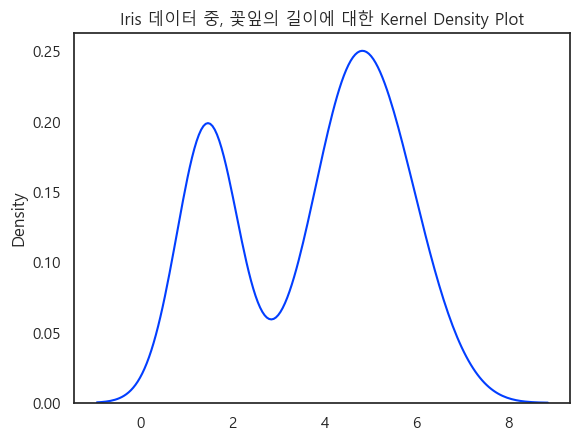

In [12]:
# Kernel Density Plot
# (주석 추가: 커널 밀도 추정(KDE) 그래프는 데이터의 분포를 히스토그램 같은 막대가 아닌, 
# 산 모양의 부드러운 곡선 형태로 연결해서 보여주는 그래프입니다. 
# 곡선의 봉우리가 높을수록 그 구간에 데이터가 빽빽하게 많이 모여 있다는 것을 의미합니다.)

# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns
# 그래프의 세부 설정과 화면 출력을 담당하는 matplotlib.pyplot 모듈을 불러옵니다.
import matplotlib.pyplot as plt

# seaborn에서 제공하는 기본 예제 데이터인 '붓꽃(iris)' 데이터셋을 불러옵니다.
iris = sns.load_dataset("iris")

# 붓꽃 데이터 중 'petal_length'(꽃잎의 길이) 열의 데이터 값들만 추출하여 변수 'x'에 저장합니다.
x = iris.petal_length.values

# --- 한글 폰트 및 깨짐 방지 설정 시작 ---
# 그래프 제목 등에 들어가는 한글이 깨지지 않도록 기본 폰트를 '맑은 고딕(Malgun Gothic)'으로 설정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'
# 한글 폰트 적용 시 축의 음수(-) 기호가 깨지는 현상을 방지해 주는 설정입니다.
plt.rcParams['axes.unicode_minus'] = False
# --- 한글 폰트 및 깨짐 방지 설정 끝 ---

# 추출한 데이터 'x'(꽃잎의 길이)를 바탕으로 커널 밀도 추정 그래프(KDE Plot)를 그립니다.
# 이 함수가 내부적으로 복잡한 수학적 계산을 거쳐 데이터를 가장 잘 나타내는 부드러운 곡선을 만들어냅니다.
sns.kdeplot(x)

# 그래프 위쪽에 표시될 제목(Title)을 설정합니다.
plt.title('Iris 데이터 중, 꽃잎의 길이에 대한 Kernel Density Plot')

# 지금까지 설정한 내용들을 바탕으로 최종 완성된 곡선 그래프를 화면에 출력합니다.
plt.show()

<Axes: xlabel='total_bill', ylabel='Density'>

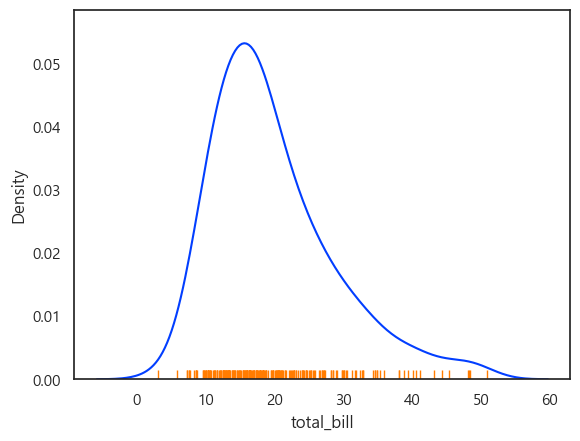

In [44]:
# 앞서 따로 알아보았던 커널 밀도 추정(KDE) 곡선과 러그 플롯(Rug Plot)을
# 하나의 그래프 화면에 겹쳐서 그리는 코드입니다.

# 1. 부드러운 산 모양의 곡선(KDE Plot) 그리기
# 'tips' 데이터셋에서 'total_bill'(총 청구 금액) 데이터를 가져와 전체적인 분포를 곡선으로 그립니다.
# 이 선이 높게 솟아오른 구간을 보면 "아, 사람들이 이 금액대에서 밥을 가장 많이 먹었구나" 하고
# 전반적인 흐름(큰 그림)을 한눈에 파악할 수 있습니다.
sns.kdeplot(data = tips, x="total_bill")

# 2. 실제 데이터의 위치(Rug Plot) 표시하기
# 위와 똑같이 'tips'의 'total_bill' 데이터를 사용해, 실제 결제 금액 하나하나가 
# x축 위의 어느 위치에 있는지 바닥에 짧은 선분(rug)으로 그어줍니다.
# 곡선(KDE)의 봉우리가 가장 높은 곳 아래를 보면, 실제로 러그(선분)들이 새까맣게 
# 뭉쳐 있는 것을 직접 눈으로 교차 검증(디테일 확인)할 수 있습니다.
sns.rugplot(data = tips, x="total_bill")

# KDE PLOT

C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_20676\1257164951.py:28: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, kde=True, rug=True)


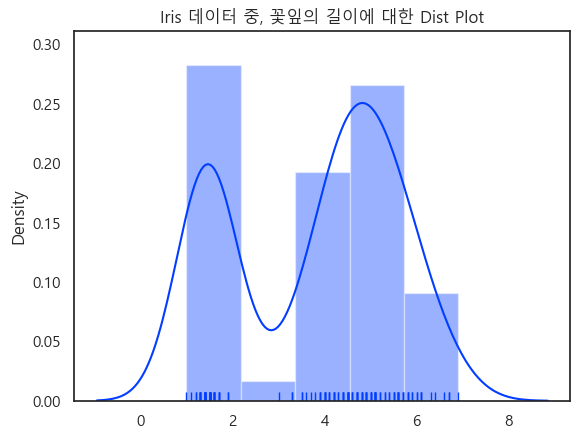

In [45]:
# Kernel Density Plot
# (이전까지 따로 그렸던 분포 그래프들을 한 번에 모아서 그리는 과정입니다.)

# 데이터 시각화를 위한 seaborn 라이브러리와
# 그래프 세부 설정 및 출력을 위한 matplotlib.pyplot 모듈을 불러옵니다.
import seaborn as sns
import matplotlib.pyplot as plt

# seaborn에 내장된 '붓꽃(iris)' 예제 데이터셋을 불러옵니다.
iris = sns.load_dataset("iris")

## 붓꽃 데이터 중 'petal_length'(꽃잎의 길이) 열의 데이터 값들만 
#추출하여 변수 'x'에 저장합니다.
x = iris.petal_length.values

## 그래프 제목 등에 들어갈 한글이 깨지지 않도록 기본 폰트를 
#'맑은 고딕(Malgun Gothic)'으로 설정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False
# (주석 추가: 이 줄은 현재 앞에 '#'이 붙어있어 실행되지 않는 상태입니다. 
# 만약 그래프의 x축이나 y축에 음수(-) 값이 들어가는데 기호가 깨져 보인다면, 
# 앞의 '#'을 지워서 이 코드를 활성화해주시면 정상적으로 출력됩니다.)

# distplot은 데이터의 분포를 종합적으로 보여주는 아주 강력한 함수입니다.
# 기본적으로 막대기 모양의 '히스토그램(Histogram)'을 그려주며,
## kde=True 옵션을 통해 앞서 배운 '부드러운 밀도 곡선'을 히스토그램 
#위에 겹쳐서 그려줍니다.
## rug=True 옵션을 통해 x축 바닥에 실제 데이터의 위치를 나타내는 
#'러그 플롯'까지 한 번에 그려줍니다.
# 즉, 3가지 시각화 기법을 이 한 줄의 코드로 모두 합쳐서 보여주는 역할을 합니다.
sns.distplot(x, kde=True, rug=True)

# 그래프 위쪽에 표시될 제목(Title)을 설정합니다.
plt.title('Iris 데이터 중, 꽃잎의 길이에 대한 Dist Plot')

# 최종적으로 완성된 그래프를 화면에 출력합니다.
plt.show()

C:\Users\NT371B5A\AppData\Local\Temp\ipykernel_20676\2949747099.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x, kde=False, rug=False)


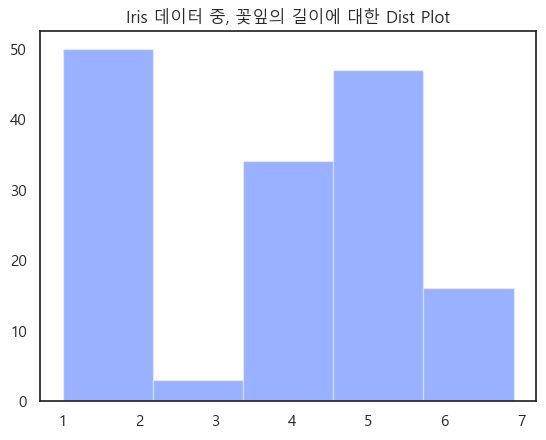

In [15]:
# Kernel Density Plot
# (주의: 메모에는 Kernel Density Plot이라고 적혀 있지만, 
## 아래 코드에서 kde=False 옵션을 주었기 때문에 실제로는 곡선이 빠진 
#'히스토그램(Histogram)'만 그려집니다!)

# 데이터 시각화를 위한 seaborn 라이브러리와 
# 세부 설정 및 출력을 위한 matplotlib.pyplot 모듈을 불러옵니다.
import seaborn as sns
import matplotlib.pyplot as plt

# seaborn에 내장된 '붓꽃(iris)' 예제 데이터셋을 불러옵니다.
iris = sns.load_dataset("iris")

## 붓꽃 데이터 중 'petal_length'(꽃잎의 길이) 열의 데이터만 
#추출하여 변수 'x'에 저장합니다.
x = iris.petal_length.values

## 그래프 제목 등에 들어갈 한글이 깨지지 않도록 기본 폰트를 
#'맑은 고딕(Malgun Gothic)'으로 설정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

plt.rcParams['axes.unicode_minus'] = False
## (축의 마이너스 기호 깨짐을 방지하는 코드입니다. 
#현재는 주석 처리되어 실행되지 않습니다.)

# distplot을 그리되, 이전과 달리 옵션을 끄는(False) 설정을 하셨습니다.
# kde=False: 부드러운 밀도 추정 곡선(KDE)을 숨깁니다.
# rug=False: x축 바닥의 데이터 위치 선분(Rug)을 숨깁니다.
## 두 옵션을 모두 껐기 때문에, 이 코드는 오직 데이터의 분포를
# 막대 모양으로 보여주는 '히스토그램'만 깔끔하게 그려냅니다.
sns.distplot(x, kde=False, rug=False)

# 그래프 위쪽에 표시될 제목(Title)을 설정합니다.
plt.title('Iris 데이터 중, 꽃잎의 길이에 대한 Dist Plot')

# 최종적으로 완성된 히스토그램을 화면에 출력합니다.
plt.show()

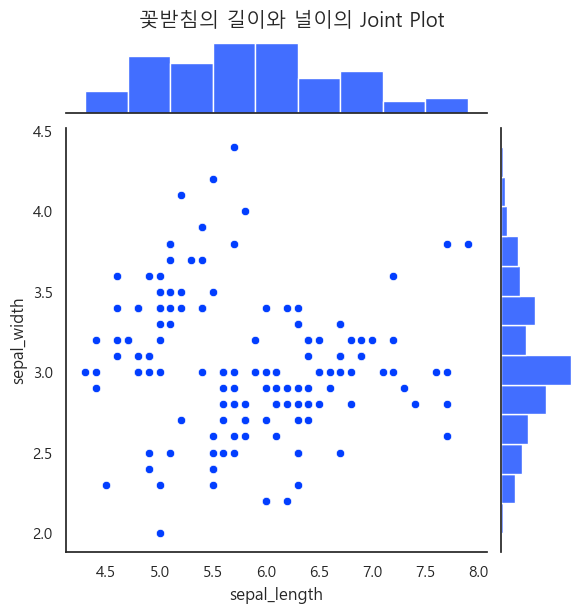

In [16]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 참고: 아래 코드에서 plt.suptitle(), plt.show() 등을 사용하시려면 
# matplotlib.pyplot 모듈이 필요합니다. 실행 시 에러가 나지 않도록 추가해 두었습니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 붓꽃(iris) 데이터셋을 불러와 'iris' 변수에 데이터프레임 형태로 저장합니다.
iris = sns.load_dataset('iris')

# --- [작성해 주신 메모 원본] ---
# data란 키워드 파일에 iris를 넣음 데이터 프레임만 넣을 수 있음
# kind = 스케터 / 산점도를 그리고 있다.
# join plot는 산점도와 히스토그램을 같이 보여주는 역할을 한다.
# scatter이 기본값이다.
# -----------------------------

# jointplot을 그려줍니다. 작성하신 메모처럼 중앙에는 두 변수(x, y)의 관계를 나타내는 산점도(scatter)가,
# 위쪽과 오른쪽 테두리에는 각각 데이터의 분포를 보여주는 히스토그램이 함께 그려집니다.
# x축에는 꽃받침의 길이(sepal_length), y축에는 꽃받침의 너비(sepal_width)를 매칭했습니다.
sns.jointplot(x='sepal_length', y='sepal_width', data=iris, kind='scatter') 

# 그래프 제목에 들어갈 한글이 깨지지 않도록 폰트를 '맑은 고딕'으로 지정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

# jointplot은 산점도와 히스토그램 등 여러 그래프가 묶여 있는 구조라서, 
# 일반적인 plt.title() 대신 전체를 아우르는 큰 제목인 plt.suptitle() (Super Title)을 사용해야 합니다.
# 주석에 남겨주신 y=1.02 옵션은 제목을 기본 위치(1.0)보다 살짝 위로 끌어올려서 
# 그래프 본문과 글자가 겹치지 않도록 깔끔하게 여백을 만들어 주는 아주 디테일하고 훌륭한 설정입니다!
# (작은 팁: '널이'는 '너비(width)'의 오타인 것 같으니 참고해 주세요 😊)
plt.suptitle('꽃받침의 길이와 널이의 Joint Plot', y=1.02) # y는 y축의 간격을 의미한다.

# 최종적으로 완성된 다중 그래프(Joint Plot)를 화면에 출력합니다.
plt.show()

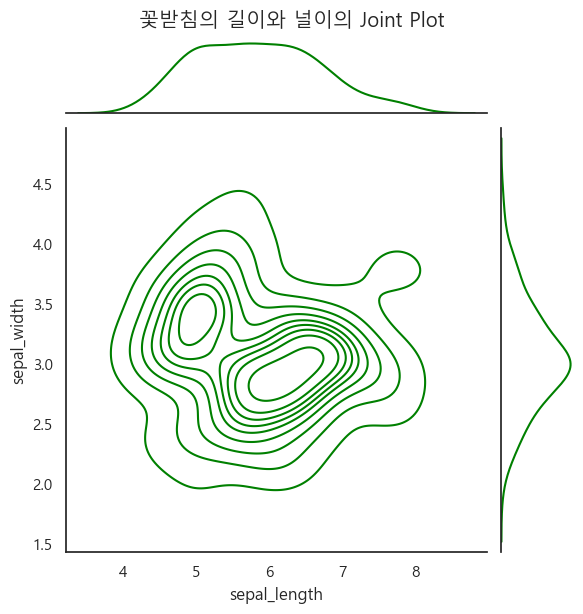

In [17]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 참고: 아래에서 plt.suptitle()과 plt.show()를 사용하기 위해 matplotlib.pyplot을 추가로 불러옵니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 붓꽃(iris) 데이터셋을 불러와 'iris' 변수에 데이터프레임 형태로 할당합니다.
iris = sns.load_dataset('iris')

# --- [작성해 주신 메모 원본] ---
# data란 키워드 파일에 iris를 넣음 데이터 프레임만 넣을 수 있음
# kind = 스케터 / 산점도를 그리고 있다.
# join plot는 산점도와 히스토그램을 같이 보여주는 역할을 한다.
# scatter이 기본값이다.
# scatter가 기본값인데 kde를 사용해서 등고선의 형태로 나타내 주는 방식을 현재 사용하고 있다.
# -----------------------------

# jointplot을 사용하여 두 변수의 관계와 각각의 분포를 한 번에 보여줍니다.
# 작성하신 메모처럼 kind='kde' 옵션을 사용했기 때문에, 중심부에는 점(scatter) 대신
# 지도의 등고선처럼 데이터가 빽빽하게 밀집된 곳일수록 겹겹이 진하게 나타나는 2차원 밀도 그래프가 그려집니다.
# 덤으로 바깥쪽 테두리(위, 오른쪽)에도 막대기(히스토그램) 대신 부드러운 산 모양의 곡선(KDE)이 그려집니다.
# color='g' 옵션은 그래프의 전체적인 색상을 초록색(green의 약자)으로 시원하게 바꿔줍니다.
sns.jointplot(x='sepal_length', y='sepal_width', data=iris, kind='kde', color='g') 

# 그래프 제목에 한글을 쓸 때 네모 모양으로 깨지는 것을 방지하기 위해 폰트를 '맑은 고딕'으로 설정합니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

# jointplot 전체를 아우르는 큰 제목(Super Title)을 설정합니다. 
# y=1.02 옵션을 통해 제목의 위치를 기본(1.0)보다 살짝 위로 올려 그래프 본문과 깔끔하게 분리해 줍니다.
plt.suptitle('꽃받침의 길이와 널이의 Joint Plot', y=1.02) # y는 y축의 간격을 의미한다.

# 최종적으로 완성된 초록빛 등고선 모양의 다중 그래프를 화면에 출력합니다.
plt.show()

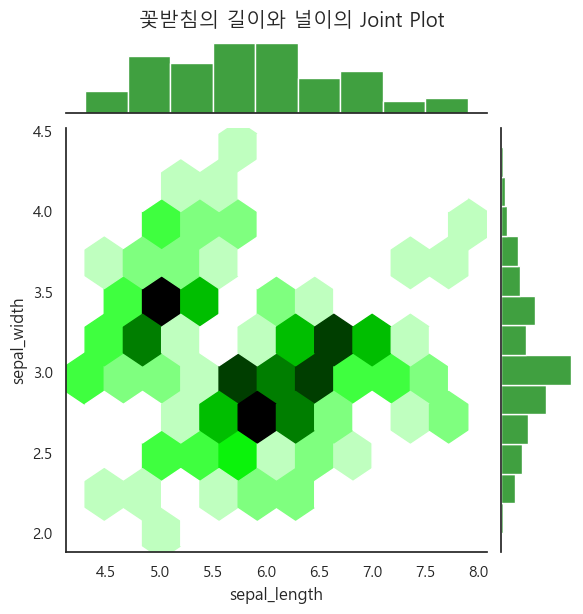

In [18]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 추가: 그래프 제목 설정(suptitle)과 출력(show)을 위해 matplotlib.pyplot을 불러옵니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 붓꽃(iris) 데이터셋을 불러와 데이터프레임 형태로 저장합니다.
iris = sns.load_dataset('iris')

# --- [작성해 주신 메모 원본] ---
# data란 키워드 파일에 iris를 넣음 데이터 프레임만 넣을 수 있음
# kind = 스케터 / 산점도를 그리고 있다.
# join plot는 산점도와 히스토그램을 같이 보여주는 역할을 한다.
# scatter이 기본값이다.
# scatter가 기본값인데 kde를 사용해서 등고선의 형태로 나타내 주는 방식을 현재 사용하고 있다.
# -----------------------------

# jointplot을 그려 두 변수의 관계를 파악합니다.
# (주석: 메모에는 kde라고 적혀있지만, 실제 코드에서는 kind='hex'를 훌륭하게 적용해 주셨습니다!)
# kind='hex'는 화면을 육각형(벌집 모양) 격자로 나눈 뒤, 각 육각형 안에 데이터(점)가 
# 얼마나 많이 들어있는지를 색상의 진하기로 표현하는 방식입니다.
# 점이 수천, 수만 개라서 까맣게 뭉쳐 보일 때 데이터의 밀도를 파악하기에 가장 최적화된 방법입니다.
# color='g'를 통해 전체적인 테마를 초록색으로 맞췄습니다.
sns.jointplot(x='sepal_length', y='sepal_width', data=iris, kind='hex', color='g') 

# 그래프 제목에 들어갈 한글이 네모로 깨지지 않도록 '맑은 고딕' 폰트를 설정해 줍니다.
plt.rcParams['font.family'] = 'Malgun Gothic'

# jointplot 전체를 아우르는 큰 제목을 달아줍니다.
# y=1.02를 통해 제목의 위치를 위로 살짝 띄워 그래프 본문과 겹치지 않게 하는 디테일을 유지했습니다.
plt.suptitle('꽃받침의 길이와 널이의 Joint Plot', y=1.02) # y는 y축의 간격을 의미한다.

# 완성된 벌집 모양의 다중 그래프를 화면에 띄워줍니다.
plt.show()

# countplot
- 항목별 데이터의 개수를 자동으로 세어서 막대그래프로 그려주는 함수
- 

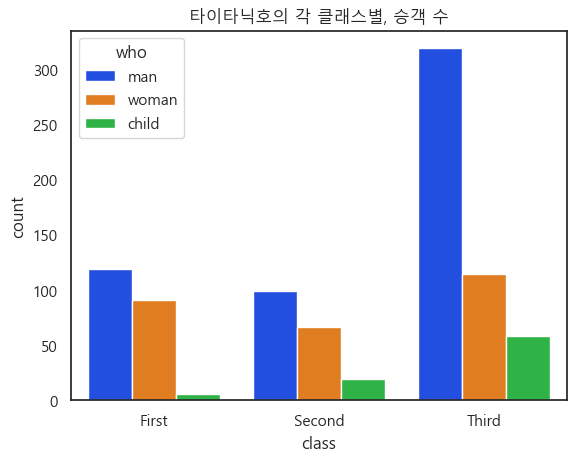

In [19]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 추가: 아래에서 plt.rcParams, plt.title, plt.show() 등의 함수를 사용하기 위해 
# matplotlib.pyplot 모듈이 반드시 필요하므로 추가해 두었습니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 유명한 예제 데이터인 '타이타닉(titanic)' 탑승객 데이터를 불러와 변수에 저장합니다.
titanic = sns.load_dataset('titanic')

# countplot은 항목별 데이터의 개수(빈도수)를 자동으로 세어서 막대그래프로 그려주는 아주 편리한 함수입니다.
# x='class' : x축에 객실 등급(First, Second, Third)을 배치합니다.
# data=titanic : 우리가 방금 불러온 타이타닉 데이터프레임을 시각화에 사용합니다.
# 
# --- [작성해 주신 메모 원본] ---
# hue : 카테고리를 기술하는 부분 
# -----------------------------
# (추가 설명: 메모해주신 대로 hue는 데이터를 특정 카테고리로 한 번 더 쪼개주는 역할을 합니다. 
# hue='who'를 지정했기 때문에, 각 객실 등급 안에서도 막대가 '남자(man)', '여자(woman)', '아이(child)' 
# 3가지로 나뉘어 각각 다른 색상으로 표시됩니다.)
sns.countplot(x='class', data=titanic, hue='who') # hue : 카테고리를 기술하는 부분 

# 그래프 제목에 한글을 입력했을 때 글자가 네모로 깨지는 것을 방지하기 위해 
# 기본 폰트를 '맑은 고딕(Malgun Gothic)'으로 설정해 줍니다.
plt.rcParams['font.family']='Malgun Gothic'

# 그래프의 최상단에 표시될 제목을 지정해 줍니다. 앞서 폰트 설정을 했으므로 한글이 예쁘게 나옵니다.
plt.title('타이타닉호의 각 클래스별, 승객 수')

# 지금까지 설정한 카운트 플롯, 한글 폰트, 제목을 모두 반영하여 최종 그래프를 화면에 띄워줍니다.
plt.show()

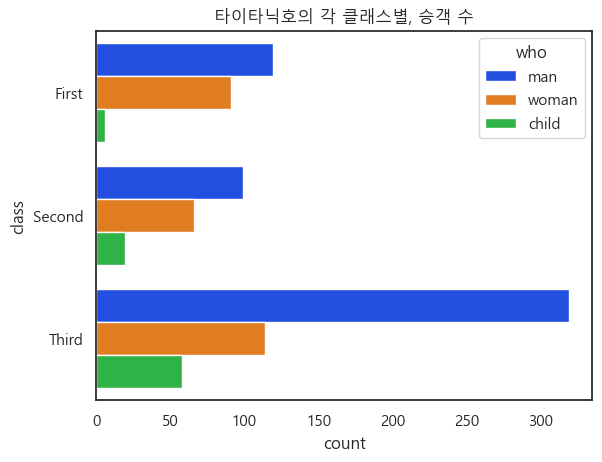

In [20]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 추가: 아래에서 plt.rcParams, plt.title, plt.show()를 사용하기 위해 추가했습니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 '타이타닉(titanic)' 예제 데이터를 불러와 데이터프레임으로 할당합니다.
titanic = sns.load_dataset('titanic')

# 이전 코드와 달리 x 대신 y축에 'class'(객실 등급)를 지정하셨습니다!
# 이렇게 설정하면 세로로 서 있던 막대그래프가 가로 방향(수평)으로 눕혀져서 그려집니다.
# 카테고리 이름이 너무 길어서 x축에 두면 글씨가 겹칠 때 아주 유용하게 쓰이는 고급 스킬입니다.
# data=titanic: 타이타닉 데이터를 사용합니다.
#
# --- [작성해 주신 메모 원본] ---
# hue : 카테고리를 기술하는 부분 
# -----------------------------
# (추가 설명: hue='who'를 통해 각 등급별 막대를 다시 남자, 여자, 아이로 쪼개어 보여줍니다.)
sns.countplot(y='class', data=titanic, hue='who') # hue : 카테고리를 기술하는 부분 

# 한글 제목이 깨지는 현상을 방지하기 위해 기본 폰트를 '맑은 고딕'으로 설정합니다.
plt.rcParams['font.family']='Malgun Gothic'

# 그래프 상단에 한글로 된 제목을 달아줍니다.
plt.title('타이타닉호의 각 클래스별, 승객 수')

# 가로로 깔끔하게 눕혀진 최종 카운트 플롯(Count Plot)을 화면에 출력합니다.
plt.show()

# Pairplot
- 데이터의 전체적인 윤곽을 잡을 때 사용하는 코드 


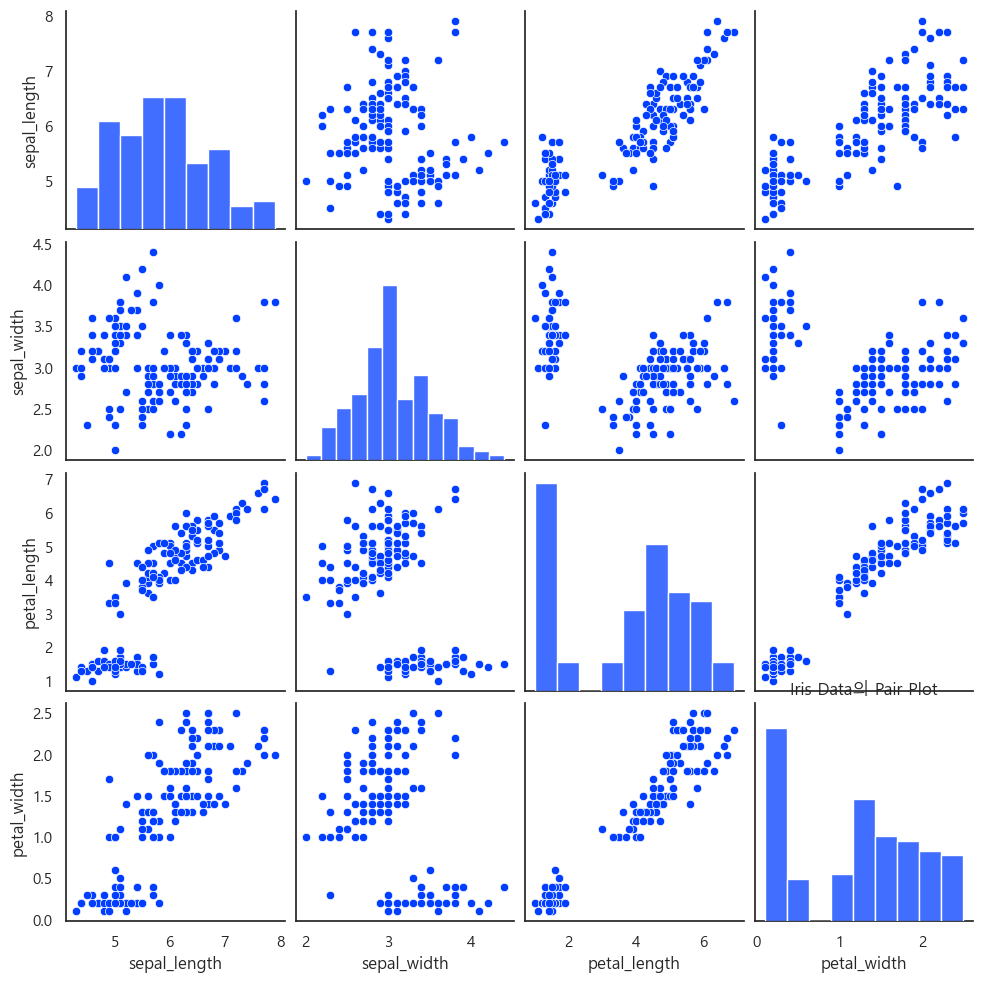

In [46]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 추가: 아래에서 plt.title()과 plt.show()를 사용하기 위해 
# matplotlib.pyplot 모듈을 추가로 불러왔습니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 '붓꽃(iris)' 예제 데이터를 불러와 데이터프레임으로 저장합니다.
# 붓꽃 데이터에는 꽃받침(sepal)의 길이/너비, 꽃잎(petal)의 길이/너비 등 총 4개의 숫자 데이터가 있습니다.
iris = sns.load_dataset('iris')

# (💡 추가: 한글 제목이 깨지는 현상을 방지하기 위해 폰트를 '맑은 고딕'으로 설정합니다.)
plt.rcParams['font.family'] = 'Malgun Gothic'

# pairplot은 데이터프레임에 들어있는 모든 숫자형 데이터의 짝을 알아서 지어줍니다.
# 숫자 변수가 4개이므로 4x4, 즉 총 16개의 그래프를 한 화면에 바둑판처럼 쫙 깔아주는 아주 강력한 함수입니다.
# 
# [그래프를 읽는 방법]
# 1. 대각선 위치 (자기 자신과의 만남): 데이터가 어떻게 퍼져있는지 분포를 보여주는 히스토그램이 그려집니다.
# 2. 나머지 위치 (서로 다른 변수와의 만남): 두 변수의 상관관계를 보여주는 산점도(Scatter Plot)가 그려집니다.
sns.pairplot(iris)

# 전체 그래프의 제목을 달아줍니다. 
# (참고: pairplot은 여러 그래프가 뭉쳐있는 형태라서 plt.title()을 쓰면 제목이 맨 마지막 그래프 쪽에 
# 치우쳐서 나올 수 있습니다. 중앙에 예쁘게 달고 싶을 때는 이전처럼 plt.suptitle()을 활용하는 것이 좋습니다!)
plt.title('Iris Data의 Pair Plot')

# 완성된 16개의 다중 그래프 묶음을 한 번에 화면에 출력합니다.
plt.show()

In [48]:
# 위의 코드와 다른 점은 KDE의 형태로 지정해줌

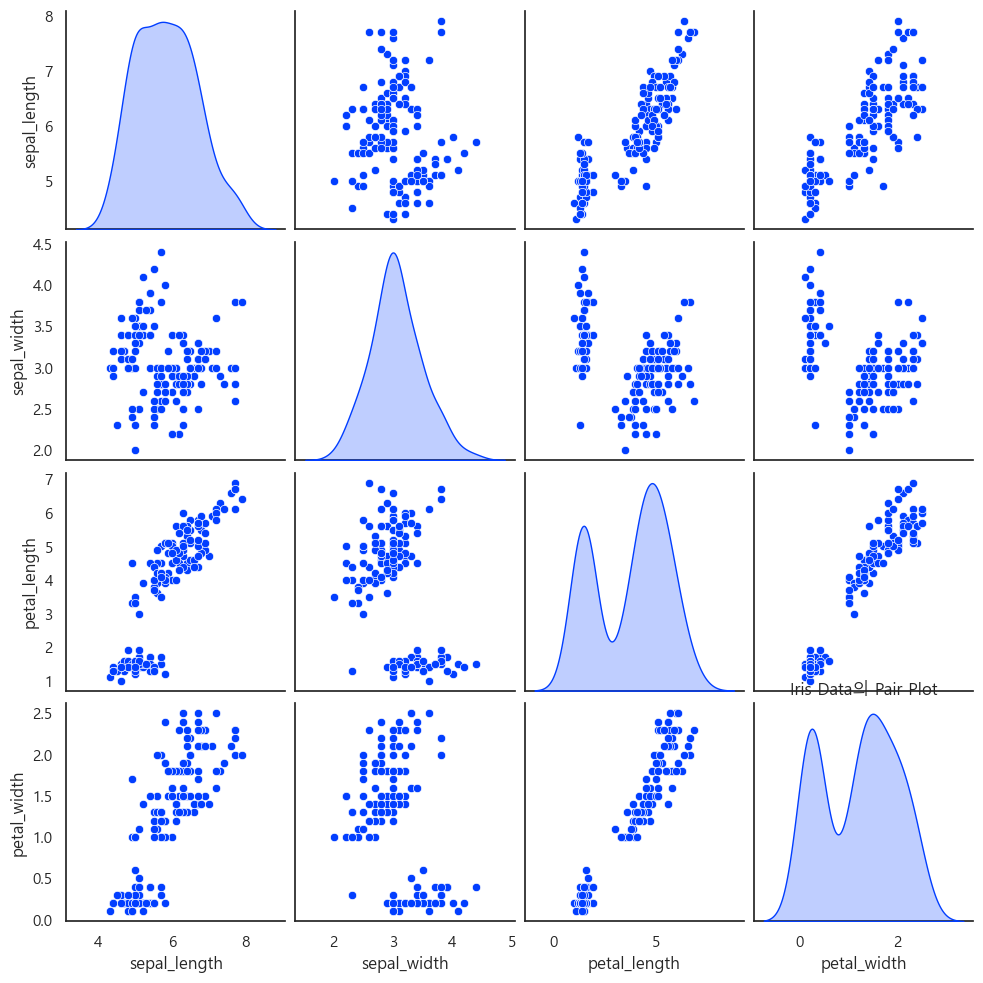

In [49]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 추가: 아래에서 plt.title()과 plt.show()를 사용하기 위해 
# matplotlib.pyplot 모듈을 추가로 불러왔습니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 '붓꽃(iris)' 예제 데이터를 불러와 데이터프레임으로 저장합니다.
iris = sns.load_dataset('iris')

# (💡 추가: 한글 제목 깨짐 현상을 방지하기 위해 폰트를 '맑은 고딕'으로 설정합니다.)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# pairplot을 그려 4가지 숫자 변수 간의 모든 짝꿍 조합을 한 화면에 그립니다.
# 
# [새롭게 추가하신 핵심 옵션: diag_kind='kde']
# 'diag'는 대각선(diagonal)을 의미합니다. 즉, 16개의 바둑판 그래프 중
# 왼쪽 위에서 오른쪽 아래로 이어지는 대각선 위치(자기 자신의 분포를 보여주는 곳)의 
# 그래프 종류(kind)를 지정하는 옵션입니다.
# 이를 'kde'로 설정했기 때문에, 기존의 투박한 막대그래프(히스토그램) 대신 
# 데이터의 밀도를 보여주는 부드러운 산 모양의 곡선(Kernel Density Estimate)으로 그려지게 됩니다.
sns.pairplot(iris, diag_kind='kde')

# 그래프의 제목을 달아줍니다. 
# (팁: pairplot에서 plt.title()을 쓰면 맨 마지막(오른쪽 아래) 그래프 위에만 작게 제목이 붙을 수 있습니다. 
# 전체를 아우르는 중앙 제목을 원하신다면 이전처럼 plt.suptitle('제목', y=1.02)를 사용하시는 것이 더 예쁩니다!)
plt.title('Iris Data의 Pair Plot')

# 완성된 다중 그래프 묶음을 화면에 출력합니다.
plt.show()

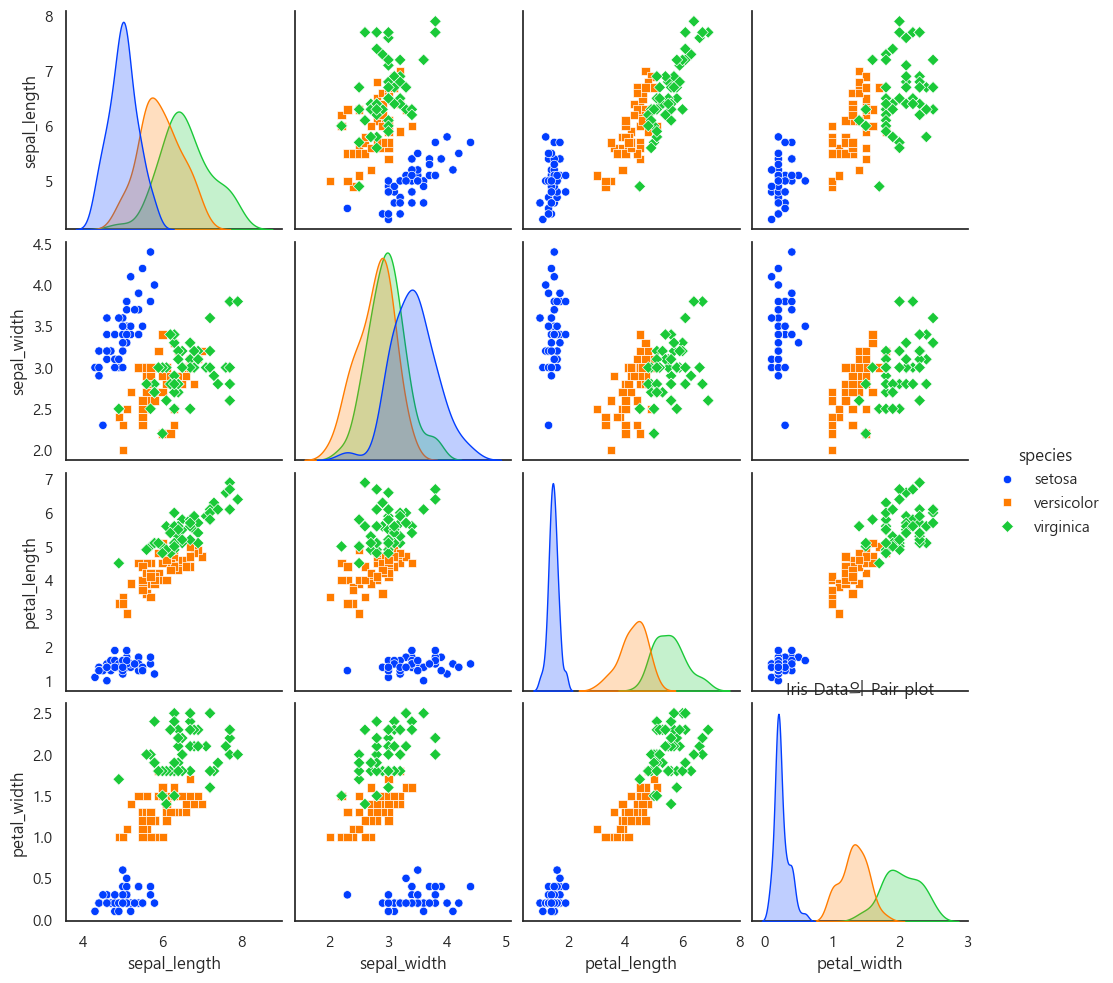

In [23]:
# 데이터 시각화를 위한 seaborn 라이브러리를 불러옵니다.
import seaborn as sns

# (💡 필수 추가: 그래프 제목 설정과 화면 출력을 위해 matplotlib.pyplot 모듈이 필요합니다.)
import matplotlib.pyplot as plt

# seaborn에 내장된 '붓꽃(iris)' 데이터셋을 불러옵니다.
iris = sns.load_dataset('iris')

# (💡 추가: 한글 제목이 깨지지 않도록 '맑은 고딕' 폰트를 설정합니다.)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# [이번 코드의 핵심: pairplot의 고급 옵션 활용]
# 1. iris: 시각화할 데이터프레임을 지정합니다.
# 2. diag_kind='kde': 대각선 위치(자기 자신)에 막대그래프 대신 부드러운 밀도 곡선을 그립니다.
# 3. hue='species': 붓꽃의 종(Setosa, Versicolor, Virginica)에 따라 색상을 다르게 칠합니다. 
#    이 옵션 하나로 데이터가 종별로 어떻게 뭉쳐 있는지(군집) 단번에 파악됩니다.
# 4. markers=['o', 's', 'D']: 각 종을 나타내는 점의 모양을 다르게 설정합니다.
#    'o' (원형 / circle), 's' (사각형 / square), 'D' (다이아몬드 / diamond) 순서로 적용됩니다.
#    색각 이상이 있는 분들도 모양으로 데이터를 구분할 수 있게 돕는 아주 배려 깊은 설정입니다.
sns.pairplot(iris, diag_kind='kde', hue='species', markers=['o','s','D'])

# 전체 그래프의 제목을 설정합니다.
# (참고: pairplot처럼 복잡한 그래프는 plt.suptitle('제목', y=1.02)를 쓰면 제목이 더 예쁘게 중앙에 배치됩니다.)
plt.title('Iris Data의 Pair plot')

# 종별로 색상과 모양이 입혀진 화려한 다중 산점도 행렬을 화면에 출력합니다.
plt.show()

In [24]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [25]:
## aggfunc='size' / 집계함수 구해서 사용함
# (주석 추가: aggfunc='size'는 각 그룹에 해당하는 데이터의 '개수'를 단순히 세어주는 역할을 합니다.)

# titanic 데이터프레임을 사용하여 피벗 테이블(Pivot Table)을 생성합니다.
# 피벗 테이블은 방대한 데이터를 특정 기준에 따라 요약해서 보여주는 요약 표입니다.
#
# index='class': 표의 '행(세로축)'을 객실 등급(First, Second, Third)으로 설정합니다.
# columns='sex': 표의 '열(가로축)'을 성별(female, male)로 설정합니다.
# aggfunc='size': 각 등급별/성별별로 해당하는 탑승객이 몇 명인지 '개수(size)'를 집계합니다.
#                 (참고: 중복을 제외하고 세고 싶다면 'nunique', 평균을 구하고 싶다면 'mean' 등을 사용합니다.)
titanic_size = titanic.pivot_table(index='class', columns='sex', aggfunc='size')

# 생성된 요약 표(데이터프레임)를 출력합니다.
# 결과를 보면 각 등급별로 남성과 여성이 각각 몇 명씩 탑승했는지 한눈에 파악할 수 있는 표가 나타납니다.
titanic_size

sex,female,male
class,,
First,94,122
Second,76,108
Third,144,347


# Heatmap 히트맵
- 히트맵은 데이터프레임의 숫자 크기에 따라 색상의 진하기를 다르게 하여 
- 수많은 숫자 속에서 패턴을 한눈에 찾게 해주는 강력한 도구입니다.

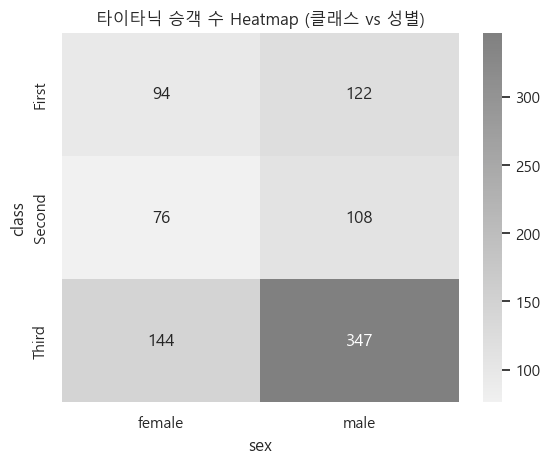

In [50]:
# 데이터 시각화를 위한 seaborn과 설정을 위한 matplotlib을 불러옵니다.
import seaborn as sns
import matplotlib.pyplot as plt

# (💡 추가: 한글 깨짐 방지를 위한 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# [히트맵(Heatmap) 그리기]
# 히트맵은 데이터프레임의 숫자 크기에 따라 색상의 진하기를 다르게 하여 
# 수많은 숫자 속에서 패턴을 한눈에 찾게 해주는 강력한 도구입니다.
#
# 1. titanic_size: 앞서 pivot_table로 만든 '객실 등급별/성별별 인원수' 데이터를 사용합니다.
# 2. cmap: 그래프의 색상 테마(Color Map)를 설정합니다. 
#    sns.light_palette('gray', as_cmap=True)는 밝은 회색 계열의 단색 테마를 사용하겠다는 뜻입니다.
# 3. annot=True: 'Annotation'의 약자로, 각 칸 안에 실제 숫자 값을 표시할지 결정합니다.
# 4. fmt='d': 'decimal'의 약자로, 숫자를 소수점이 없는 정수(Integer) 형태로 깔끔하게 표기합니다.
sns.heatmap(titanic_size, 
            cmap=sns.light_palette('gray', as_cmap=True), 
            annot=True, fmt='d')

# 그래프의 제목을 설정합니다.
plt.title('타이타닉 승객 수 Heatmap (클래스 vs 성별)')

# 최종 완성된 히트맵을 화면에 출력합니다. 
# 색이 가장 진한 곳이 인원수가 가장 많은 구간(3등석 남성 등)임을 바로 알 수 있습니다.
plt.show()

In [27]:
titanic.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


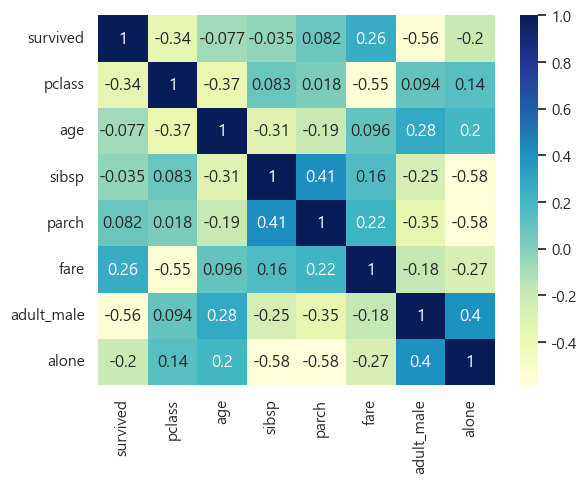

In [28]:
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()

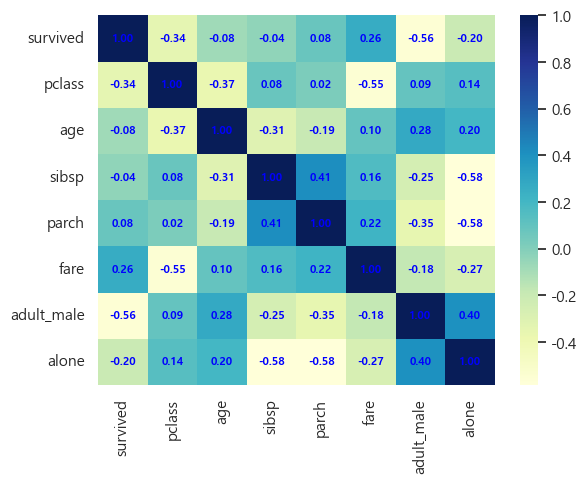

In [29]:
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap='YlGnBu',
           annot_kws={'size' : 8, 'weight':'bold', 'color':"blue"}, fmt=".2f")
plt.show()

# barplot

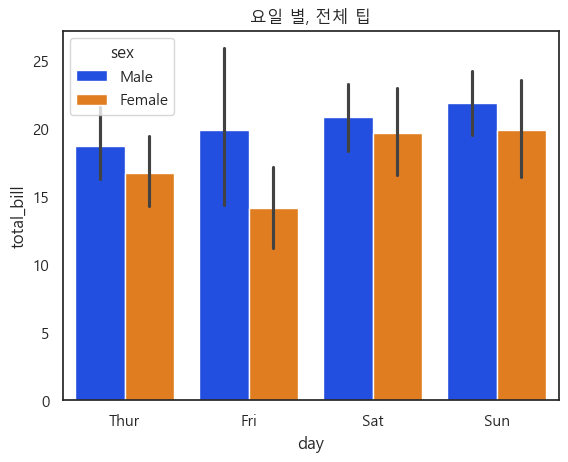

In [30]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.barplot(x='day', y='total_bill', data=tips, hue='sex')
plt.title('요일 별, 전체 팁')
plt.show()

# boxplot

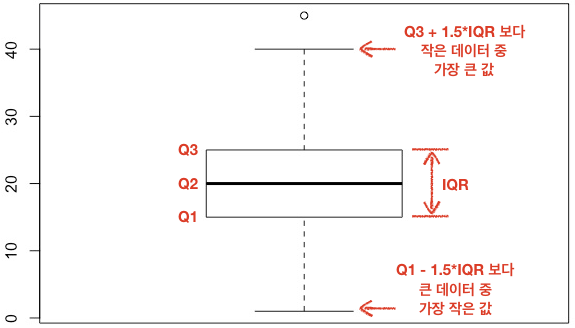

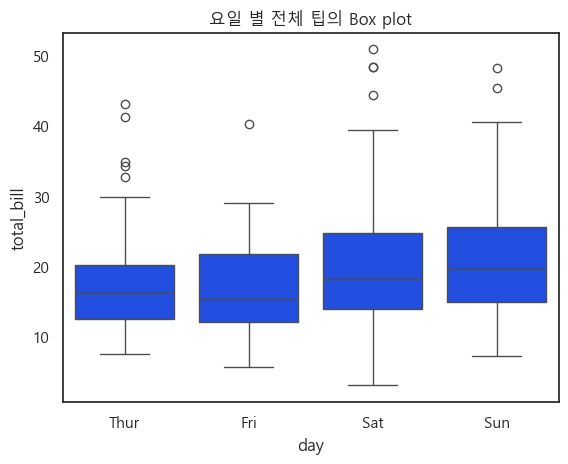

In [31]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.boxplot(x='day', y='total_bill', data=tips)
plt.title('요일 별 전체 팁의 Box plot')
plt.show()

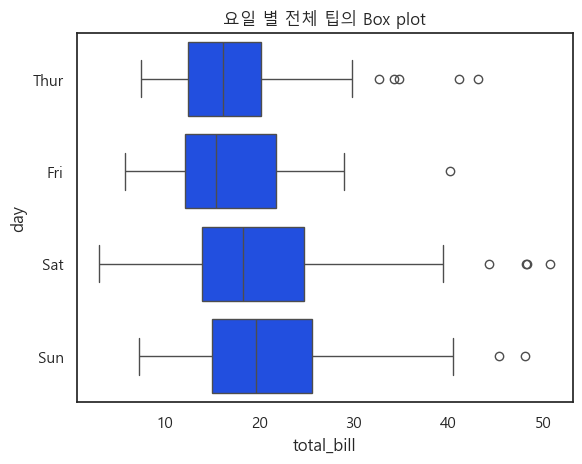

In [32]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.boxplot(y='day', x='total_bill', data=tips, orient='h')
plt.title('요일 별 전체 팁의 Box plot')
plt.show()

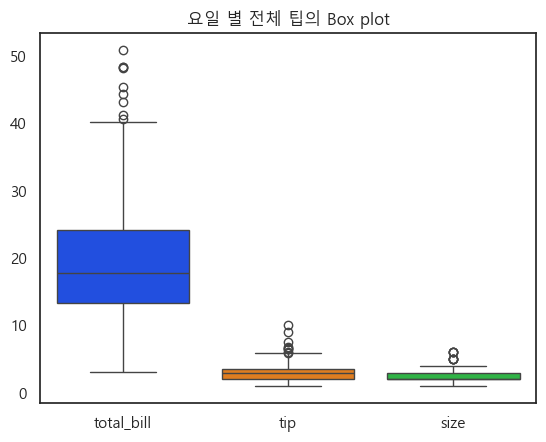

In [33]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.boxplot(data=tips, orient='v')
plt.title('요일 별 전체 팁의 Box plot')
plt.show()

# violinplot, stripplot, swarmplot

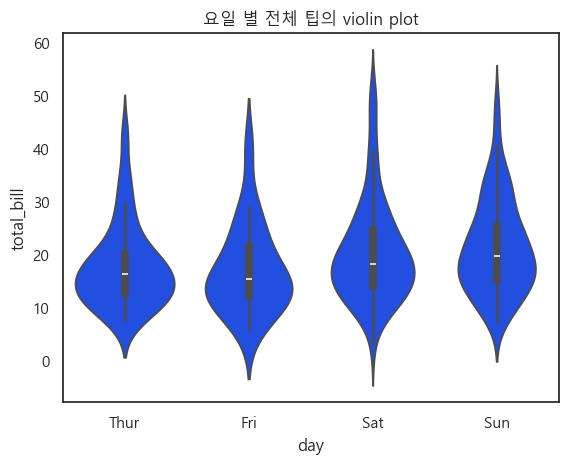

In [34]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.violinplot(x='day', y='total_bill', data=tips)
plt.title('요일 별 전체 팁의 violin plot')
plt.show()

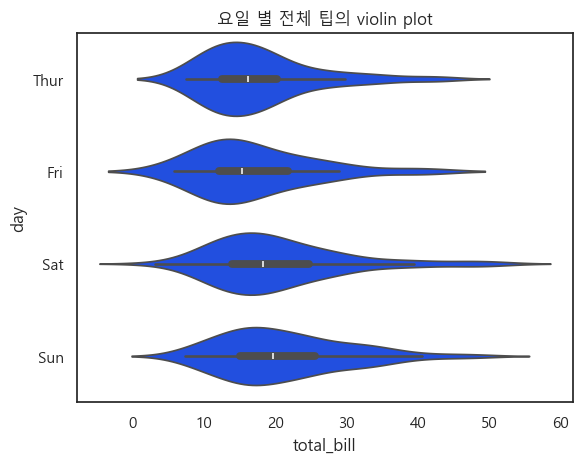

In [35]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.violinplot(y='day', x='total_bill', data=tips)
plt.title('요일 별 전체 팁의 violin plot')
plt.show()

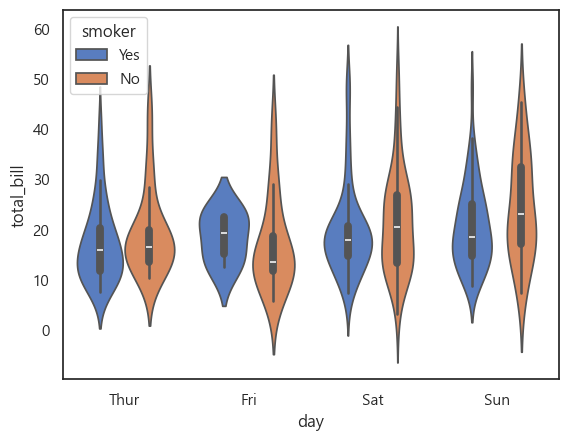

In [36]:
sns.violinplot(x='day', y='total_bill', hue='smoker', data=tips, palette='muted')
plt.show()

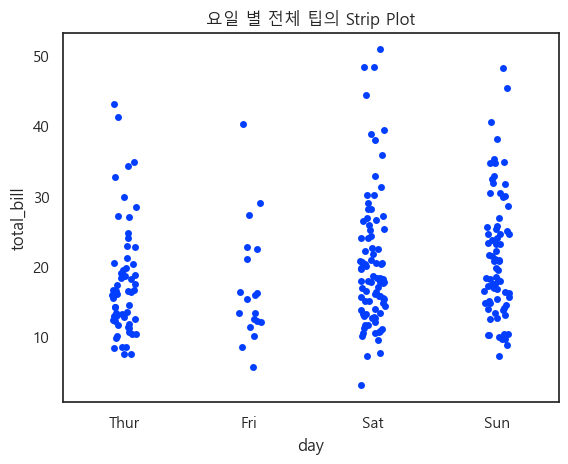

In [37]:
import seaborn as sns

tips = sns.load_dataset('tips')

# jitter 겹치는 경우 무작위 재배치한다는 의미
sns.stripplot(x='day', y='total_bill', data=tips, jitter=True)
plt.title('요일 별 전체 팁의 Strip Plot')
plt.show()

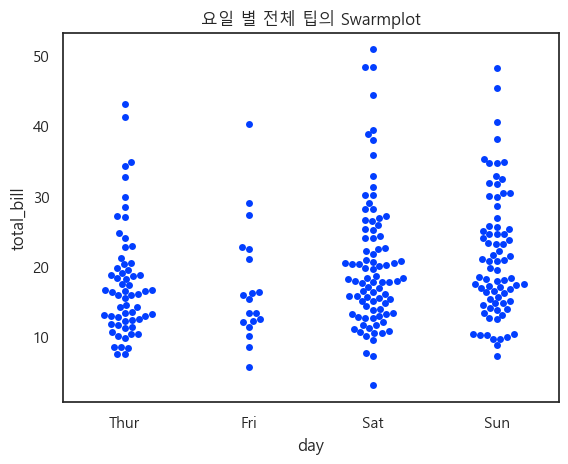

In [38]:
import seaborn as sns

tips = sns.load_dataset('tips')
sns.swarmplot(x='day', y='total_bill', data=tips)
plt.title('요일 별 전체 팁의 Swarmplot')
plt.show()

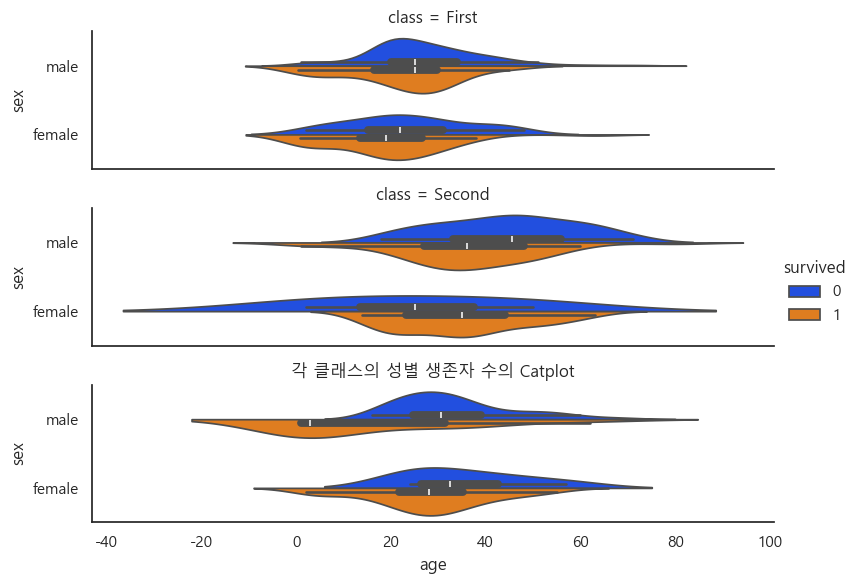

In [39]:
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['axes.unicode_minus']= False
titanic = sns.load_dataset('titanic')
data = titanic[titanic.survived.notnull()]
sns.catplot(x='age', y='sex', hue='survived', row='class', data=data,
           kind='violin', split=True, height=2, aspect=4)
plt.title('각 클래스의 성별 생존자 수의 Catplot')
plt.show()

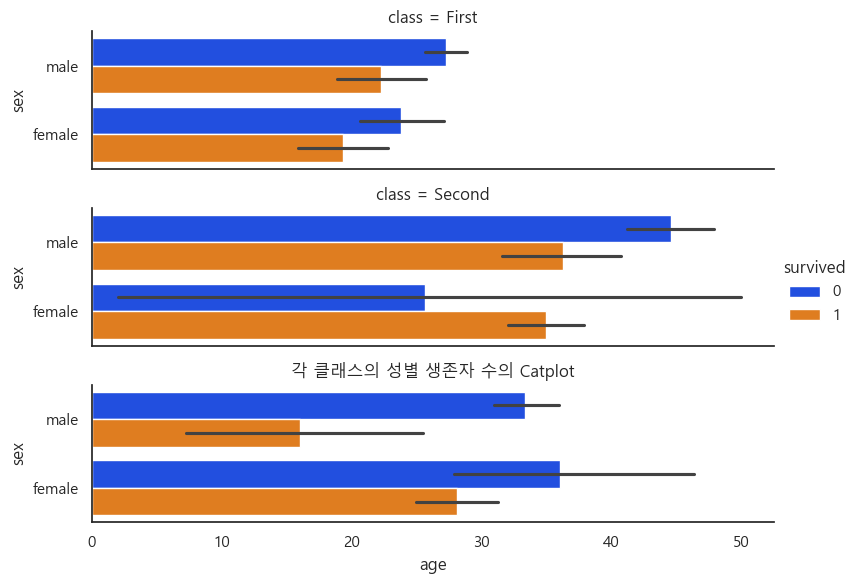

In [40]:
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['axes.unicode_minus']= False
titanic = sns.load_dataset('titanic')
data = titanic[titanic.survived.notnull()]
sns.catplot(x='age', y='sex', hue='survived', row='class', data=data,
           kind='bar', height=2, aspect=4)
plt.title('각 클래스의 성별 생존자 수의 Catplot')
plt.show()

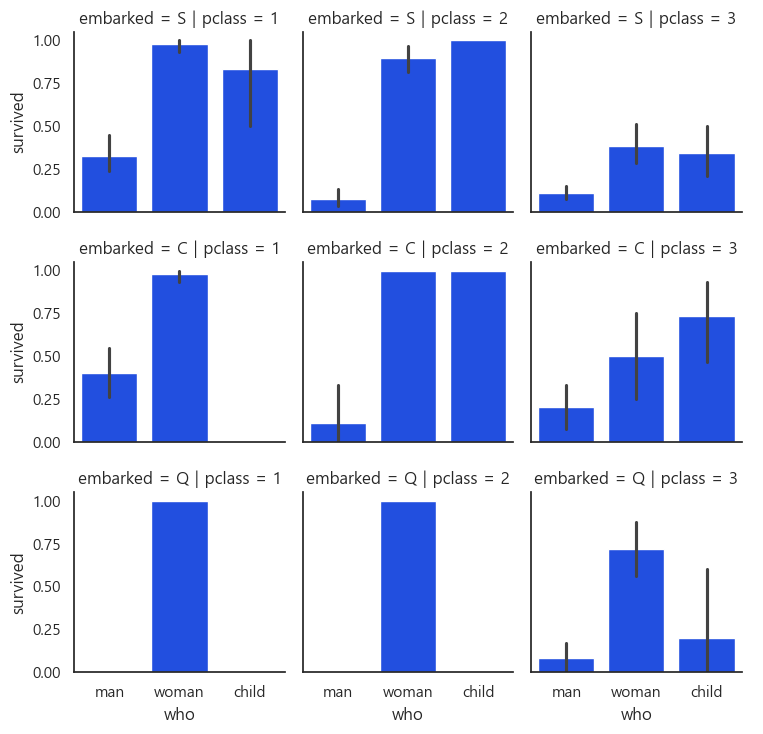

In [41]:
sns.catplot(x='who', y='survived', col='pclass', 
            row='embarked', kind='bar', height=2.5, 
            data=titanic)
plt.show()

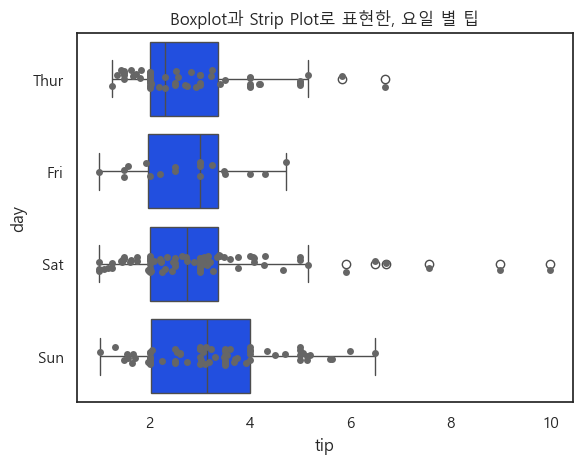

In [42]:
import seaborn as sns
import numpy as np

tips = sns.load_dataset('tips')
plt.title('Boxplot과 Strip Plot로 표현한, 요일 별 팁')
sns.boxplot(x='tip', y='day', data=tips)
sns.stripplot(x='tip', y='day', data=tips, jitter=True, color='0.4')
plt.show()

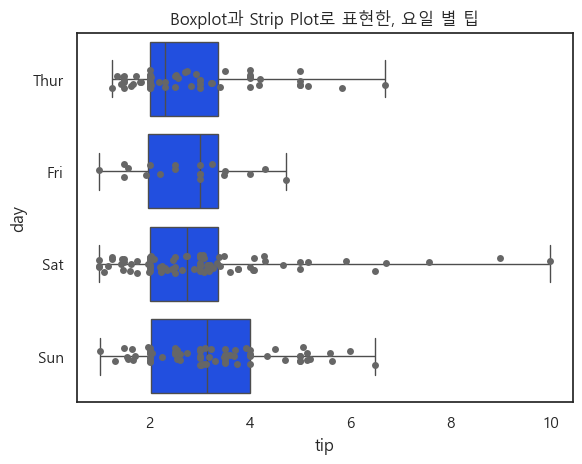

In [43]:
import seaborn as sns
import numpy as np

tips = sns.load_dataset('tips')
plt.title('Boxplot과 Strip Plot로 표현한, 요일 별 팁')
sns.boxplot(x='tip', y='day', data=tips, whis=np.inf) # whis=np.inf 파라매터에 제약을 두지 않겠다는 의미
sns.stripplot(x='tip', y='day', data=tips, jitter=True, color='0.4')
plt.show()